<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>ML & DL</b></center>

<center><b><h1>Drashti Ruparelia</b></center>
    
<center><b><h1>Lab - 14</b></center>    
<pre>   

# Lab 4: Convolutional Neural Networks (CNNs) and Image Loading -

**Objective:** In previous labs, we loaded datasets directly into memory using PyTorch's built-in datasets. In the real world, you will usually receive a hard drive or folder full of images. In this lab, you will:
1. Load image files directly from a disk directory structure.
2. Build a Convolutional Neural Network (CNN) to process 3-channel (RGB) color images.
3. Compare the spatial feature extraction of CNNs to the MLPs used in previous labs.

In [10]:
import torch
import os
import torchvision
from PIL import Image
from tqdm import tqdm

def setup_disk_dataset(root_dir='./data/cifar10_disk'):
    if os.path.exists(root_dir):
        print("Dataset already exists on disk!")
        return

    print("Saving CIFAR-10 images to disk folder structure...")
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)

    for i, (img, label) in enumerate(tqdm(trainset)):
        class_name = trainset.classes[label]
        save_dir = os.path.join(root_dir, 'train', class_name)
        os.makedirs(save_dir, exist_ok=True)
        img.save(os.path.join(save_dir, f'img_{i}.png'))
    print(f"Images saved successfully to {root_dir}/train!")

setup_disk_dataset()

Dataset already exists on disk!


### Task 1: Define Data Transformations
When loading images from disk, they are read as PIL Images. We need to convert them to PyTorch Tensors and normalize them.

**Task:** Use `torchvision.transforms.Compose` to convert the images to tensors and normalize them with a mean and standard deviation of 0.5 across all three RGB channels.

In [11]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

### Task 2: Load Dataset from Disk
PyTorch provides `torchvision.datasets.ImageFolder` to easily load images that are organized in folders named after their classes.

**Task:** Use `ImageFolder` to load the training dataset from the `./data/cifar10_disk/train` directory, applying the transform you defined in Task 1.

In [12]:
import torchvision.datasets as ImageFolder

train_dataset = ImageFolder.ImageFolder(root='./data/cifar10_disk/train', transform=transform)
print(f"Loaded {len(train_dataset)} images")
print(f"Classes {train_dataset.classes} images")

Loaded 50000 images
Classes ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'] images


In [13]:
import matplotlib.pyplot as plt
image_tensor, label = train_dataset[3]

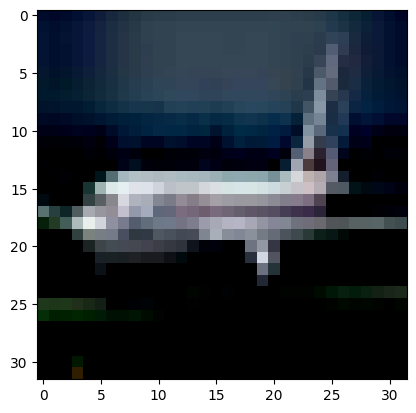

In [14]:
plt.imshow(image_tensor.permute(1,2,0))

### Task 3: Create the DataLoader
**Task:** Wrap your `train_dataset` in a `torch.utils.data.DataLoader`. Set a batch size of 64 and ensure the data is shuffled.

In [15]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

### Task 4: Build the CNN Architecture


Unlike MLPs that flatten the image immediately, CNNs use convolutional layers to extract spatial features.

**Task:** Create a class `SimpleCNN` that inherits from `nn.Module`.
Your network should have:
1. A convolutional layer (`nn.Conv2d`) taking 3 input channels, outputting 16 channels, with a kernel size of 3.
2. A ReLU activation.
3. A Max Pooling layer (`nn.MaxPool2d`) with a kernel size of 2 and stride of 2.
4. A fully connected layer (`nn.Linear`) that maps the flattened pooled features to 10 output classes. *(Hint: CIFAR-10 images are 32x32. Calculate the spatial dimensions after convolution and pooling to find the input size for the Linear layer).*

In [16]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(16 * 15 * 15, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = x.view(-1, 16 * 15 * 15) ##flatten the tensor
        x = self.fc1(x)
        return x


model = SimpleCNN()
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3600, out_features=10, bias=True)
)


### Task 5: Define Loss and Optimizer
**Task:** Initialize the Cross-Entropy Loss function and the Adam optimizer with a learning rate of 0.001.

In [17]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Task 6: The Training Loop
**Task:** Write a training loop for 5 epochs. Iterate over the `train_loader`, perform the forward pass, calculate the loss, backpropagate, and update the weights. Print the loss at the end of each epoch.

# Test

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = 5

for epoch in range(epochs):
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/5], Loss: 1.4420
Epoch [2/5], Loss: 1.2184
Epoch [3/5], Loss: 1.1359
Epoch [4/5], Loss: 1.0757
Epoch [5/5], Loss: 1.0319


In [19]:
model.eval()
correct = 0
total = 0

In [20]:
with torch.no_grad():
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

Files already downloaded and verified


In [21]:
print(f"Accuracy: {100 * correct / total:.2f}%")

Accuracy: 66.58%
